# 👥 Demographic Data Analysis
##### A data analysis project that fetches user data from the DummyJSON API, explores and cleans it, then answers key analytical questions through Seaborn visualizations.

**Source:** [DummyJSON API](https://dummyjson.com/users)  
**Tools:** Python, Pandas, Seaborn, Matplotlib

## 1. Load Data

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

df = pd.read_csv('users.csv')
print(f'✔ Loaded {len(df)} rows, {len(df.columns)} columns')
df.head()

✔ Loaded 208 rows, 28 columns


,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,NaN,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,NaN,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,NaN,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


## 2. Basic Data Exploration

In [25]:
print('Shape:', df.shape)

Shape: (208, 28)


In [26]:
print('Columns:')
print(list(df.columns))

Columns:
['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email', 'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height', 'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress', 'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto', 'role']


In [27]:
print('Data Types:')
df.dtypes

Data Types:


id              int64
firstName      object
lastName       object
maidenName     object
age             int64
gender         object
email          object
phone          object
username       object
password       object
birthDate      object
image          object
bloodGroup     object
height        float64
weight        float64
eyeColor       object
hair           object
ip             object
address        object
macAddress     object
university     object
bank           object
company        object
ein            object
ssn            object
userAgent      object
crypto         object
role           object
dtype: object

In [53]:
print('Missing Values:')
df.isnull().sum()

Missing Values:


id              0
firstName       0
lastName        0
maidenName    148
age             0
gender          0
email           0
phone           0
username        0
password        0
birthDate       0
image           0
bloodGroup      0
height          0
weight          0
eyeColor        0
hair            0
ip              0
address         0
macAddress      0
university      0
bank            0
company         0
ein             0
ssn             0
userAgent       0
crypto          0
role            0
city            0
country         0
dtype: int64

In [29]:
print(f' Duplicate Rows: {df.duplicated().sum()}')

 Duplicate Rows: 0


In [52]:
print('Summary Statistics:')
df.describe().round(2)

Summary Statistics:


,id,age,height,weight
count,208.00,208.00,208.00,208.00
mean,104.50,33.14,175.72,75.04
std,60.19,5.54,14.12,14.09
min,1.00,23.00,150.25,50.10
25%,52.75,29.00,164.19,62.55
50%,104.50,32.00,177.43,75.98
75%,156.25,36.00,186.96,86.99
max,208.00,46.00,199.81,99.54


In [31]:
print(' Value Counts — Categorical Columns:')
for col in ['gender', 'bloodGroup', 'eyeColor', 'role']:
    if col in df.columns:
        print(f'\n[{col}]')
        print(df[col].value_counts())

 Value Counts — Categorical Columns:

[gender]
gender
female    106
male      102
Name: count, dtype: int64

[bloodGroup]
bloodGroup
O-     31
B-     31
AB+    29
AB-    29
B+     25
O+     22
A+     21
A-     20
Name: count, dtype: int64

[eyeColor]
eyeColor
Brown     35
Hazel     34
Green     28
Blue      24
Gray      24
Violet    22
Red       21
Amber     20
Name: count, dtype: int64

[role]
role
user         193
moderator     10
admin          5
Name: count, dtype: int64


## 3. Data Cleaning

In [32]:
def parse_address(addr_str, key):
    try:
        addr_dict = json.loads(str(addr_str).replace("'", '"'))
        return addr_dict.get(key, 'Unknown')
    except:
        try:
            return eval(str(addr_str)).get(key, 'Unknown')
        except:
            return 'Unknown'

df['city']    = df['address'].apply(lambda x: parse_address(x, 'city'))
df['country'] = df['address'].apply(lambda x: parse_address(x, 'country'))

for col in ['age', 'height', 'weight']:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

print('✔ city & country extracted')
print('✔ Missing values handled')
df[['city', 'country']].head()

✔ city & country extracted
✔ Missing values handled


,city,country
0,Phoenix,United States
1,Houston,United States
2,Washington,United States
3,Seattle,United States
4,Jacksonville,United States


In [33]:
print('Value counts — country:')
df['country'].value_counts()

Value counts — country:


country
United States    208
Name: count, dtype: int64

## 4. Analysis

In [47]:
# Q1 - Average age
avg_age = df['age'].mean()
print(f' Average age of users: {avg_age:.2f} years')

 Average age of users: 33.14 years


In [49]:
# Q2 - Average age by gender
print(' Average age by gender:')
df.groupby('gender')['age'].mean().round(2)

 Average age by gender:


gender
female    31.38
male      34.97
Name: age, dtype: float64

In [50]:
# Q3 - Users per gender
print(' Number of users per gender:')
df['gender'].value_counts()

 Number of users per gender:


gender
female    106
male      102
Name: count, dtype: int64

In [51]:
# Q4 - Top 10 cities
print('Top 10 cities:')
df['city'].value_counts().head(10)

Top 10 cities:


city
Phoenix         17
Dallas          15
Jacksonville    14
Los Angeles     14
Seattle         12
San Jose        11
Charlotte       11
Philadelphia    11
Chicago         11
Columbus        11
Name: count, dtype: int64

In [38]:
# Q5 - Avg height & weight
print(f' Average height: {df["height"].mean():.2f} cm')
print(f'   Average weight: {df["weight"].mean():.2f} kg')

 Average height: 175.72 cm
   Average weight: 75.04 kg


In [39]:
# Q6 - Correlation
corr_h = df[['age','height']].corr().loc['age','height']
corr_w = df[['age','weight']].corr().loc['age','weight']
print(f' Pearson r — age ↔ height : {corr_h:.4f}')
print(f'   Pearson r — age ↔ weight : {corr_w:.4f}')
print('→ Weak correlation: no strong relationship between age and height/weight.')

 Pearson r — age ↔ height : 0.0235
   Pearson r — age ↔ weight : 0.0670
→ Weak correlation: no strong relationship between age and height/weight.


## 5. Visualizations

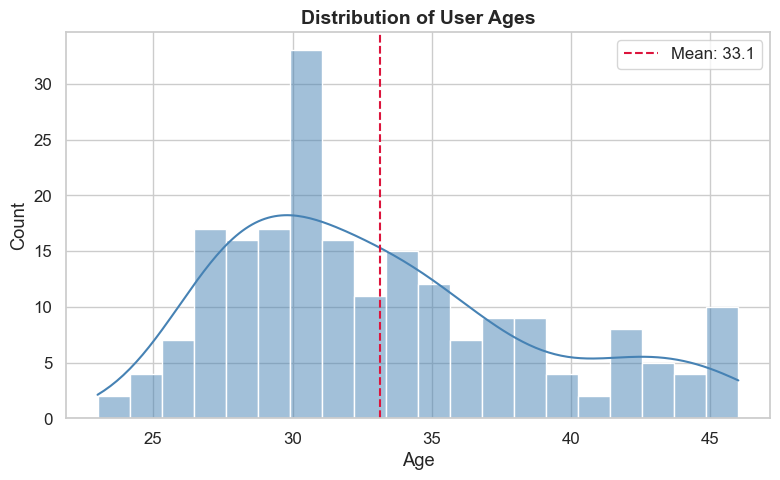

In [40]:
# Plot 1 - Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
plt.axvline(avg_age, color='crimson', linestyle='--', label=f'Mean: {avg_age:.1f}')
plt.title('Distribution of User Ages', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

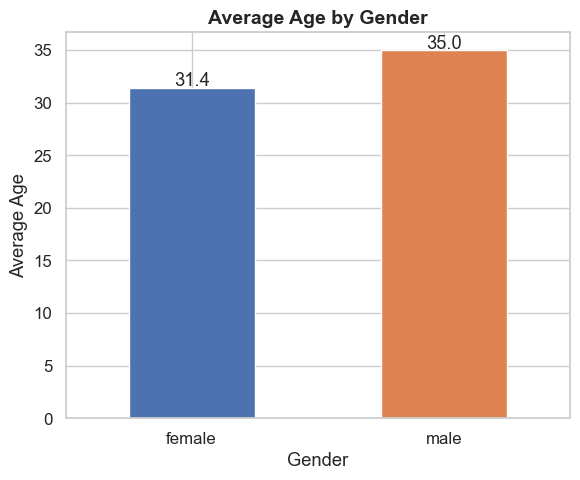

In [41]:
# Plot 2 - Avg Age by Gender
avg_age_gender = df.groupby('gender')['age'].mean().round(2)
plt.figure(figsize=(6,5))
ax = avg_age_gender.plot(kind='bar', color=['#4C72B0','#DD8452'], edgecolor='white')
plt.title('Average Age by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average Age')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', (p.get_x()+p.get_width()/2, p.get_height()+0.2), ha='center')
plt.tight_layout()
plt.show()

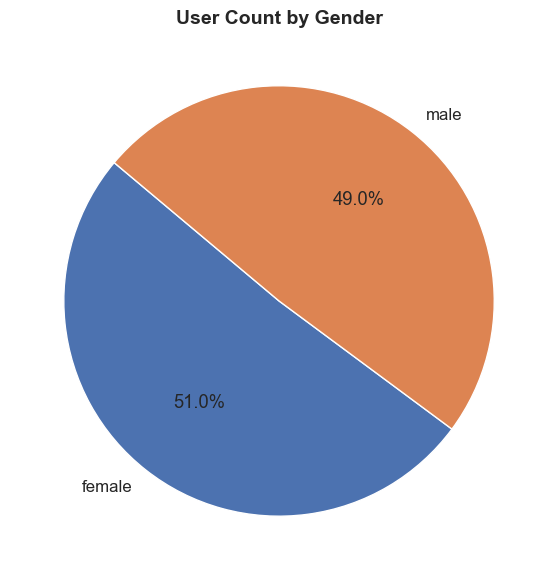

In [42]:
# Plot 3 - Gender Pie
users_gender = df['gender'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(users_gender, labels=users_gender.index, autopct='%1.1f%%',
        colors=['#4C72B0','#DD8452','#55A868'],
        startangle=140, wedgeprops=dict(edgecolor='white'))
plt.title('User Count by Gender', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

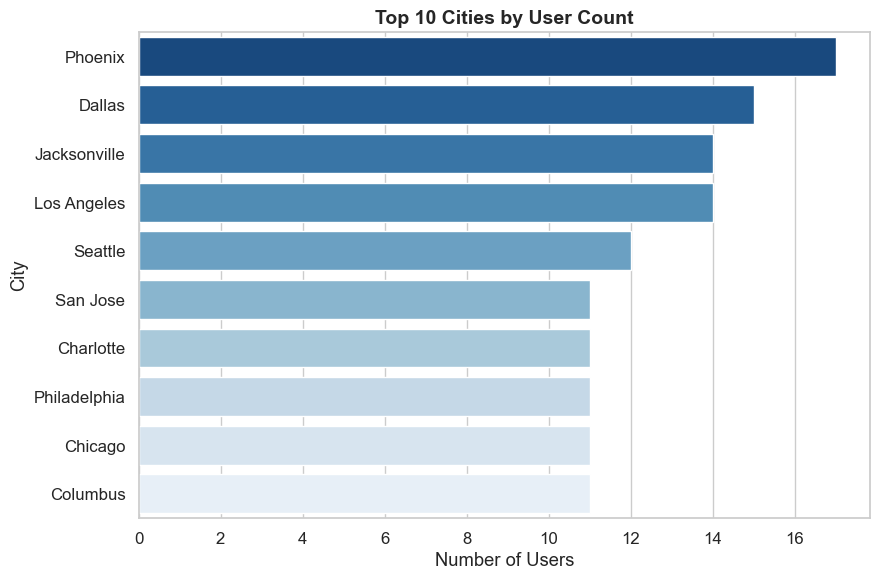

In [43]:
# Plot 4 - Top 10 Cities
top_cities = df['city'].value_counts().head(10)
plt.figure(figsize=(9,6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')
plt.title('Top 10 Cities by User Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Users')
plt.ylabel('City')
plt.tight_layout()
plt.show()

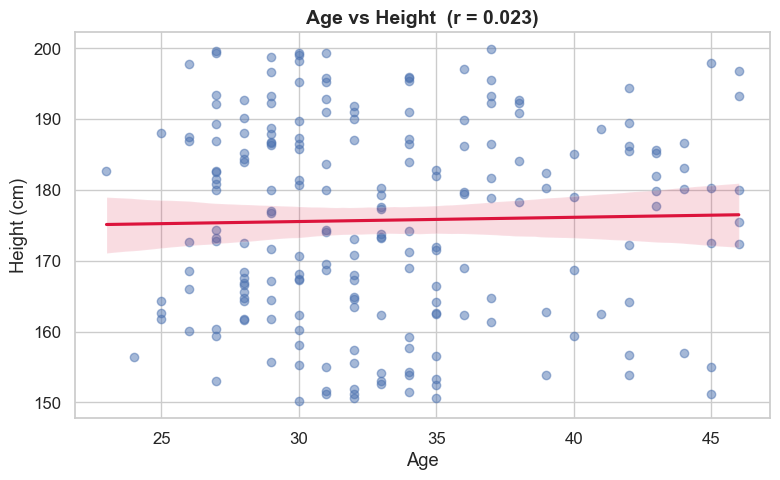

In [44]:
# Plot 5 - Age vs Height
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='age', y='height',
            scatter_kws={'alpha':0.5,'color':'#4C72B0'},
            line_kws={'color':'crimson'})
plt.title(f'Age vs Height  (r = {corr_h:.3f})', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Height (cm)')
plt.tight_layout()
plt.show()

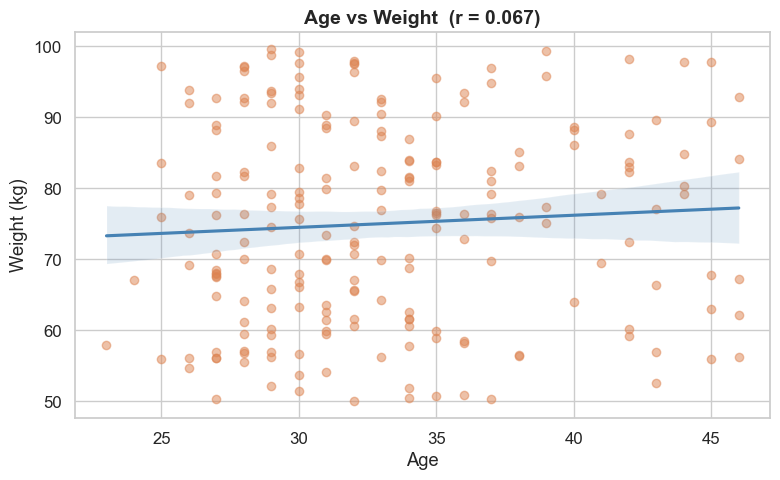

In [45]:
# Plot 6 - Age vs Weight
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='age', y='weight',
            scatter_kws={'alpha':0.5,'color':'#DD8452'},
            line_kws={'color':'steelblue'})
plt.title(f'Age vs Weight  (r = {corr_w:.3f})', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Weight (kg)')
plt.tight_layout()
plt.show()

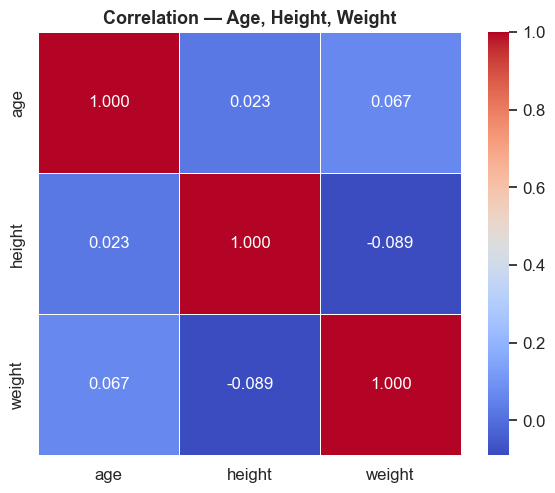

In [46]:
# Plot 7 - Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df[['age','height','weight']].corr(),
            annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, square=True, annot_kws={'size':12})
plt.title('Correlation — Age, Height, Weight', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

THANK YOU 